

# FCC-ee Impedance Model


It is designed for the FCC-ee IW repository structure:
```text
FCCee_IW_2026_V1/Coll_taper_3deg/
├── Impedances/
    ├── Devices/
    └── Total/
├── Plots/
├── Simulation_files/
├── Utilities&Docu/
└── Wakes/

```
What it does:

1. Reads the individual device impedance files from `Impedance/Devices`and the total saved from `Impedance/Total` and plots them.
2. Allows the user to select an arbitrary subset of devices and produces the related impedance.

In [1]:
%matplotlib widget

from pathlib import Path

import importlib
import utils_impedance

#importlib.reload(utils_impedance)

from utils_impedance import (
    read_impedance_devices,
    read_total_impedance,
    get_device_contributions,
    plot_stacked_impedance,
    sum_selected_impedances,
    save_total_impedance_test,
    plot_total_impedance,
    load_total_impedance
)

In [2]:
MODEL_FOLDER = Path.cwd().parent

DEVICES_FOLDER = MODEL_FOLDER / "Impedances" / "Devices"
PLOTS_FOLDER = MODEL_FOLDER / "Plots"
TOTAL_FOLDER = MODEL_FOLDER / "Impedances" / "Total"

#TOTAL_FOLDER.mkdir(exist_ok=True)
#PLOTS_FOLDER.mkdir(exist_ok=True)

In [3]:
SELECTED_DEVICES = [
    "optimizedKicker",
    "collSA3cm",
    "pipe_rw",
    "SRabs",
    "ems",
    "stripkickers26",
    "IR",
    "flanges",
    "int_mod",
    "bpm",
    "RF"
]

# Plot impedance contributuon of different devices

In [4]:

plane = "dipx"  # quadx or quady to do the same for quadrupolar impedances

frequency, devices = read_impedance_devices(DEVICES_FOLDER, plane)

# Keep only selected devices
devices = {name: Z for name, Z in devices.items() if name in SELECTED_DEVICES}

Z_contributions, labels, colors = get_device_contributions(devices)

Looking in: /home/cantuono/fcc_ee_IW_model/FCCee_IW_2026/FCCee_IW_2026_V2/Coll_taper_3deg/Impedances/Devices
Pattern: Z_dipx_*.txt
Files found:
   Z_dipx_IR.txt
   Z_dipx_RF.txt
   Z_dipx_SRabs.txt
   Z_dipx_bpm.txt
   Z_dipx_collSA3cm.txt
   Z_dipx_ems.txt
   Z_dipx_flanges.txt
   Z_dipx_int_mod.txt
   Z_dipx_optimizedKicker.txt
   Z_dipx_pipe_rw.txt
   Z_dipx_stripkickers26.txt


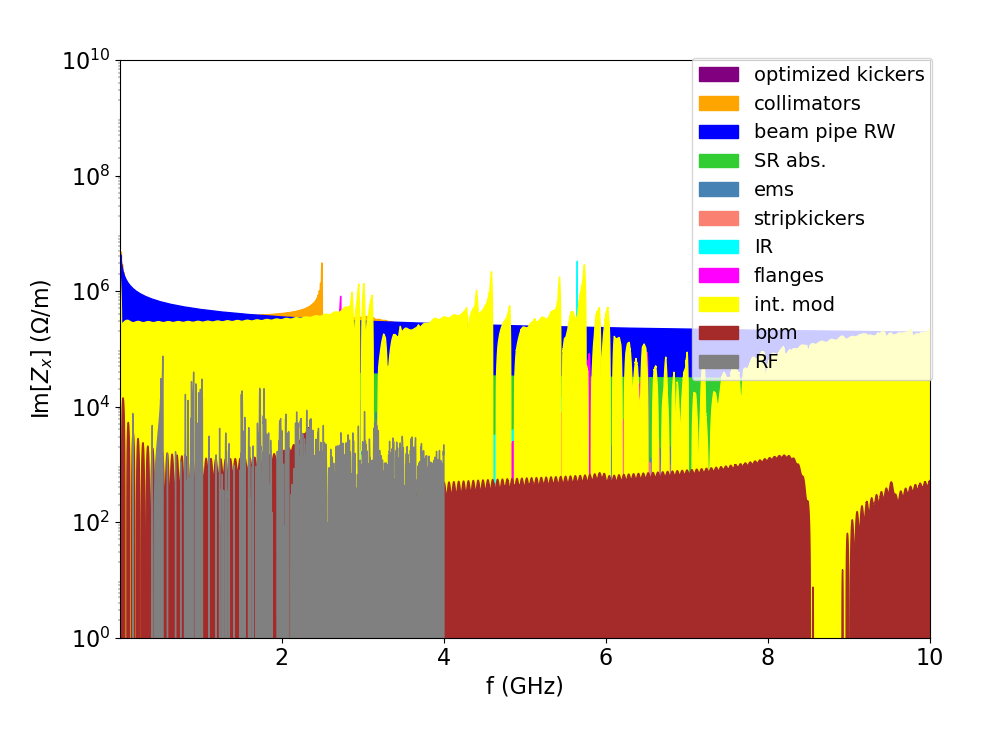

In [5]:
plot_stacked_impedance(frequency,Z_contributions,labels,colors,plane=plane,part="imag",image_folder=PLOTS_FOLDER,);

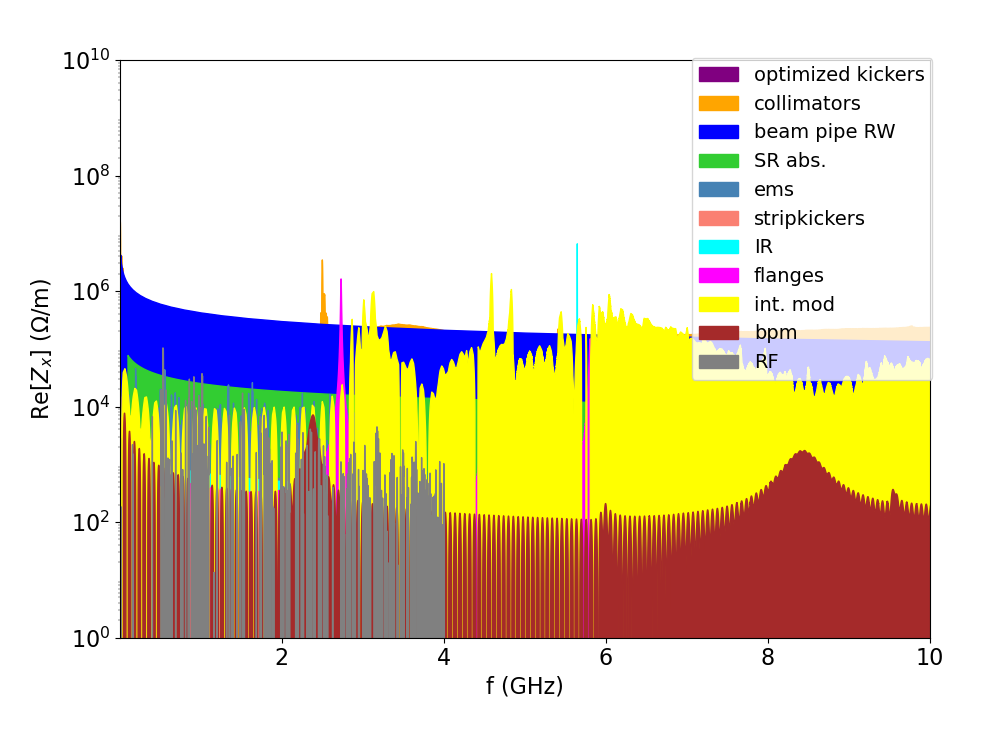

In [6]:
plot_stacked_impedance(frequency,Z_contributions,labels,colors,plane=plane,part="real",image_folder=PLOTS_FOLDER,);

In [7]:
plane = "dipy"

frequency, devices = read_impedance_devices(DEVICES_FOLDER,plane,)

Z_contributions, labels, colors = get_device_contributions(devices)

Looking in: /home/cantuono/fcc_ee_IW_model/FCCee_IW_2026/FCCee_IW_2026_V2/Coll_taper_3deg/Impedances/Devices
Pattern: Z_dipy_*.txt
Files found:
   Z_dipy_IR.txt
   Z_dipy_RF.txt
   Z_dipy_SRabs.txt
   Z_dipy_bpm.txt
   Z_dipy_collSA3cm.txt
   Z_dipy_ems.txt
   Z_dipy_flanges.txt
   Z_dipy_int_mod.txt
   Z_dipy_optimizedKicker.txt
   Z_dipy_pipe_rw.txt
   Z_dipy_stripkickers26.txt


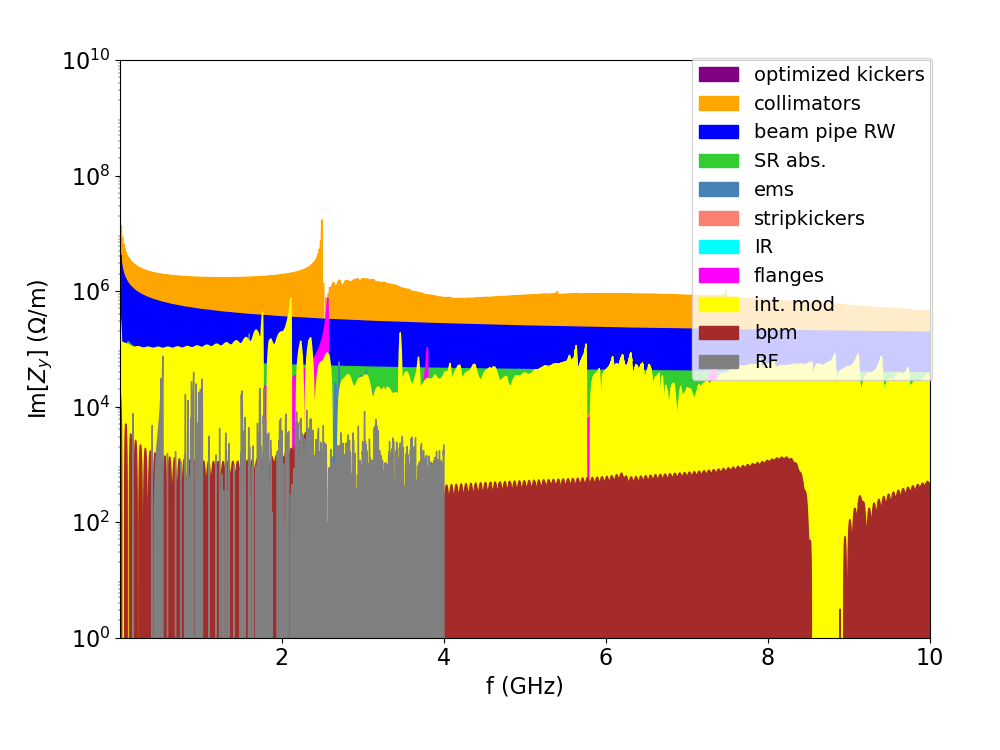

In [8]:
plot_stacked_impedance(frequency,Z_contributions,labels,colors,plane=plane,part="imag",image_folder=PLOTS_FOLDER,);

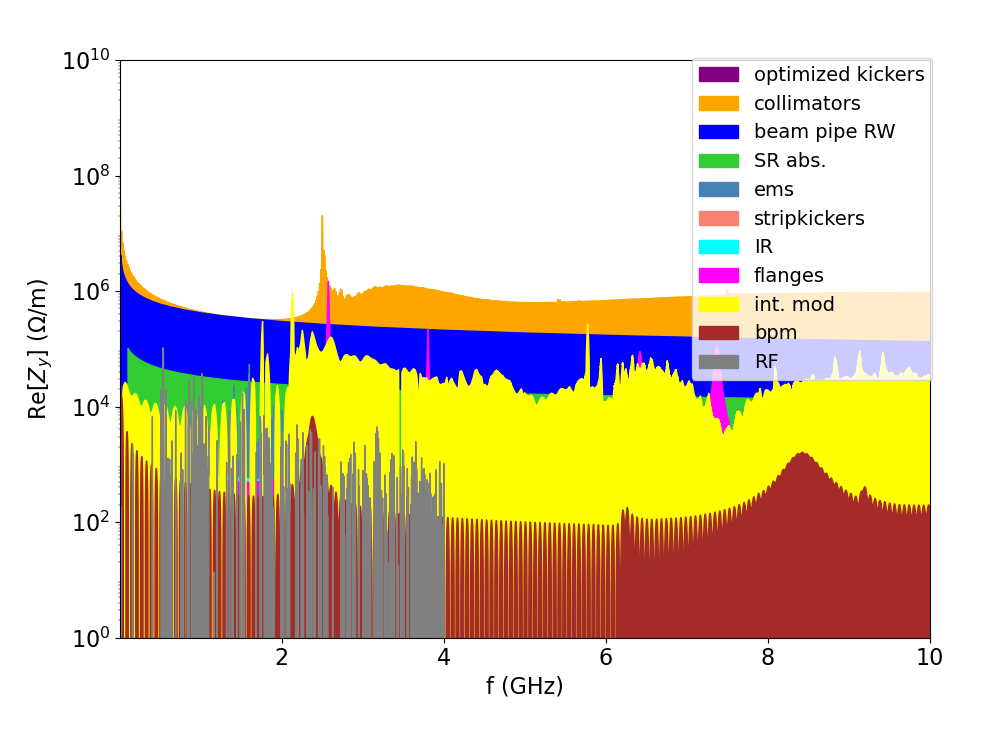

In [9]:
plot_stacked_impedance(frequency,Z_contributions,labels,colors,plane=plane,part="real",image_folder=PLOTS_FOLDER,);

In [10]:
plane = "long"

frequency, devices = read_impedance_devices(DEVICES_FOLDER,plane,)

Z_contributions, labels, colors = get_device_contributions(devices)

Looking in: /home/cantuono/fcc_ee_IW_model/FCCee_IW_2026/FCCee_IW_2026_V2/Coll_taper_3deg/Impedances/Devices
Pattern: Z_long_*.txt
Files found:
   Z_long_IR.txt
   Z_long_RF.txt
   Z_long_SRabs.txt
   Z_long_bpm.txt
   Z_long_collSA3cm.txt
   Z_long_ems.txt
   Z_long_flanges.txt
   Z_long_int_mod.txt
   Z_long_optimizedKicker.txt
   Z_long_pipe_rw.txt
   Z_long_stripkickers26.txt


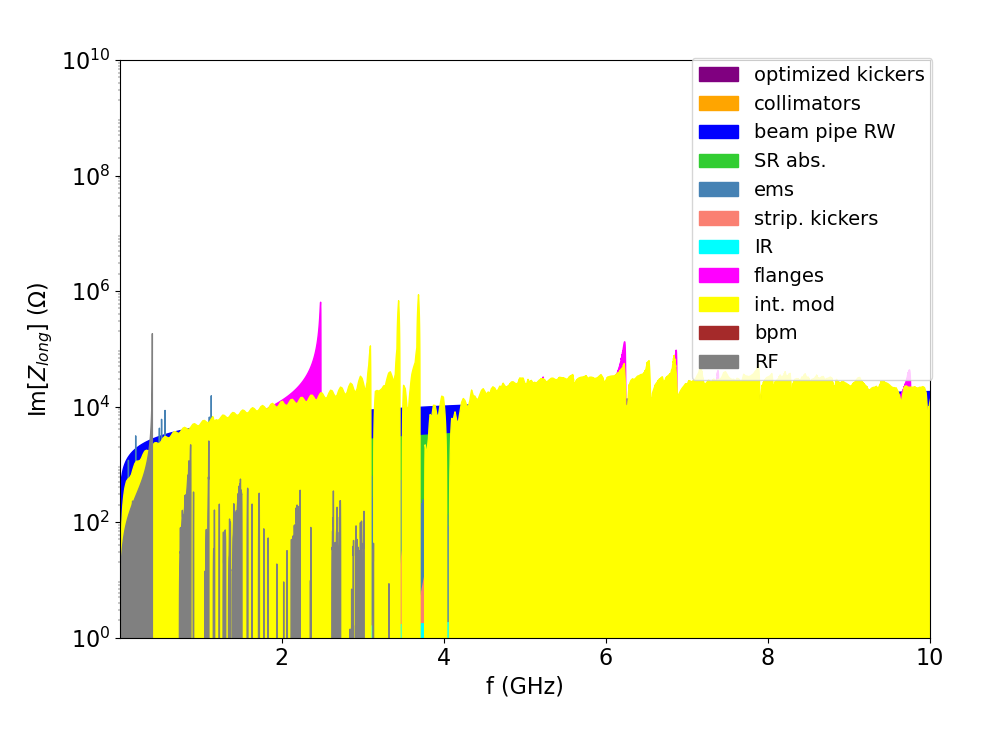

In [10]:
plot_stacked_impedance(frequency,Z_contributions,labels,colors,plane=plane,part="imag",image_folder=PLOTS_FOLDER,);

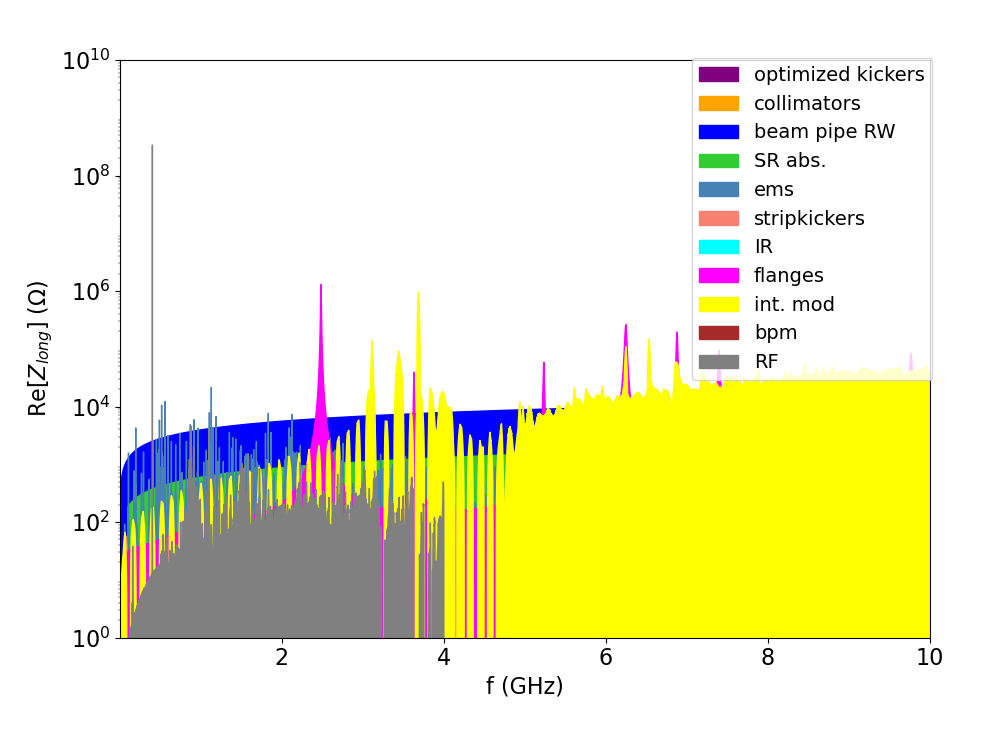

In [11]:
plot_stacked_impedance(frequency,Z_contributions,labels,colors,plane=plane,part="real",image_folder=PLOTS_FOLDER,);

# PLot total impedances stored in Impedance/Total

Example: plot the total recommended impedance, which is the current optimized version under the name "Ztotal_recommended.txt"

For more info about the content, check Utilities&Docu/fcc_ee_iw_2026_info.md

In [12]:
total_impedance_file = "Ztotal_recommended.txt"
#The name can be changed to "Ztotal_all.txt" or "Ztotal_noRF_noEMS.txt" 

(freq,Zz_tot,Zx_tot,Zy_tot,Zxquad_tot,Zyquad_tot,) = read_total_impedance(TOTAL_FOLDER,total_impedance_file,);


/home/cantuono/fcc_ee_IW_model/FCCee_IW_2026/FCCee_IW_2026_V2/Coll_taper_3deg/Utilities&Docu/utils_impedance.py:656: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt(


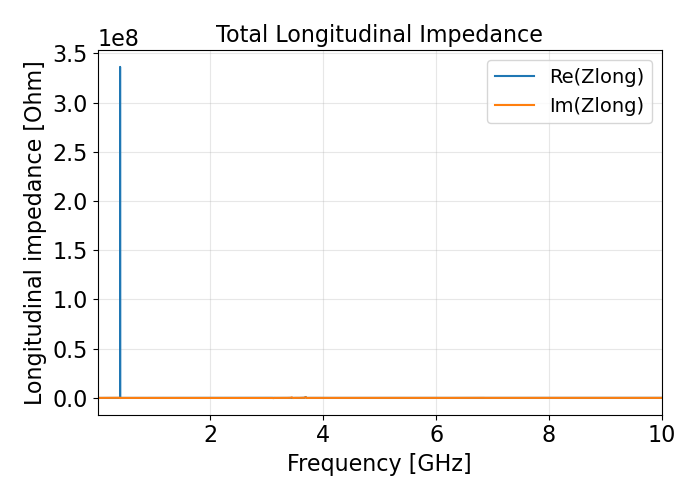

/home/cantuono/fcc_ee_IW_model/FCCee_IW_2026/FCCee_IW_2026_V2/Coll_taper_3deg/Utilities&Docu/utils_impedance.py:1126: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/home/cantuono/miniconda3/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.figure.savefig(buf, format='png', dpi='figure')


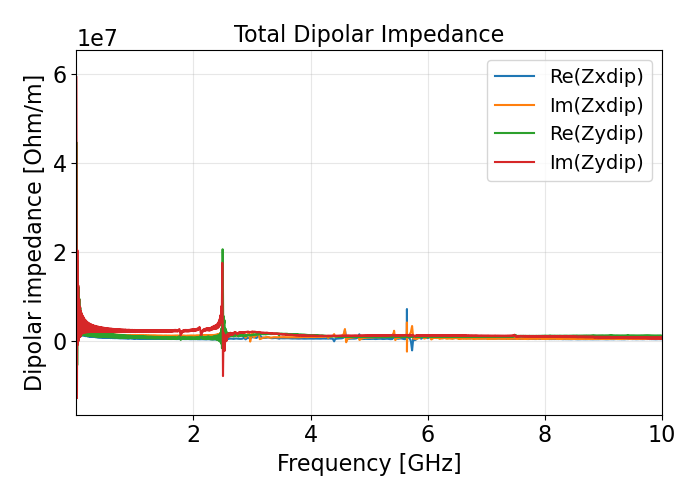

/home/cantuono/fcc_ee_IW_model/FCCee_IW_2026/FCCee_IW_2026_V2/Coll_taper_3deg/Utilities&Docu/utils_impedance.py:1183: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


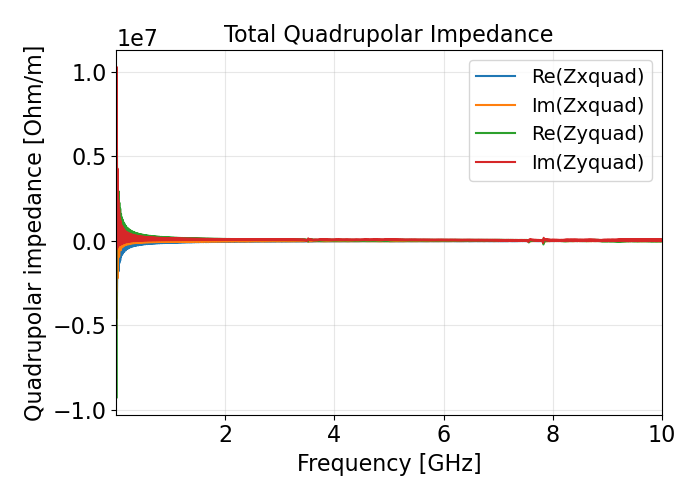

In [13]:

plot_total_impedance(frequency=freq,Zlong=Zz_tot,Zxdip=Zx_tot,Zydip=Zy_tot,Zxquad=Zxquad_tot,Zyquad=Zyquad_tot,filename=total_impedance_file,image_folder=PLOTS_FOLDER,xlim=(1e-3, 10),show=True,save=False,);

# Sum selected devices by user 

These are all the available devices for this model version:

selected_devices  = [

    "optimizedKicker",
    "coll3cm",
    "pipe_rw",
    "SRabs",
    "ems",
    "stripkickers26",
    "IR",
    "flanges",
    "int_mod",
    "bpm",
    "RF",
]


In [14]:
SELECTED_DEVICES = [
    "pipe_rw",
    "collSA3cm",
    "optimizedKicker",
    "RF",
    "bpm",
    "ems",
    "stripkickers26",
    "SRabs",
    "int_mod",
    "IR"
]

freq, devices_long = read_impedance_devices(DEVICES_FOLDER,"long",)

_, devices_dipx = read_impedance_devices(DEVICES_FOLDER,"dipx",)

_, devices_dipy = read_impedance_devices(DEVICES_FOLDER,"dipy",)

_, devices_quadx = read_impedance_devices(DEVICES_FOLDER,"quadx",)

_, devices_quady = read_impedance_devices(DEVICES_FOLDER,"quady",)


Looking in: /home/cantuono/fcc_ee_IW_model/FCCee_IW_2026/FCCee_IW_2026_V2/Coll_taper_3deg/Impedances/Devices
Pattern: Z_long_*.txt
Files found:
   Z_long_IR.txt
   Z_long_RF.txt
   Z_long_SRabs.txt
   Z_long_bpm.txt
   Z_long_collSA3cm.txt
   Z_long_ems.txt
   Z_long_flanges.txt
   Z_long_int_mod.txt
   Z_long_optimizedKicker.txt
   Z_long_pipe_rw.txt
   Z_long_stripkickers26.txt
Looking in: /home/cantuono/fcc_ee_IW_model/FCCee_IW_2026/FCCee_IW_2026_V2/Coll_taper_3deg/Impedances/Devices
Pattern: Z_dipx_*.txt
Files found:
   Z_dipx_IR.txt
   Z_dipx_RF.txt
   Z_dipx_SRabs.txt
   Z_dipx_bpm.txt
   Z_dipx_collSA3cm.txt
   Z_dipx_ems.txt
   Z_dipx_flanges.txt
   Z_dipx_int_mod.txt
   Z_dipx_optimizedKicker.txt
   Z_dipx_pipe_rw.txt
   Z_dipx_stripkickers26.txt
Looking in: /home/cantuono/fcc_ee_IW_model/FCCee_IW_2026/FCCee_IW_2026_V2/Coll_taper_3deg/Impedances/Devices
Pattern: Z_dipy_*.txt
Files found:
   Z_dipy_IR.txt
   Z_dipy_RF.txt
   Z_dipy_SRabs.txt
   Z_dipy_bpm.txt
   Z_dipy_collSA3c

In [15]:
# Sum selected devices

Zlong = sum_selected_impedances(devices_long,SELECTED_DEVICES,)

Zxdip = sum_selected_impedances(devices_dipx,SELECTED_DEVICES,)

Zydip = sum_selected_impedances(devices_dipy,SELECTED_DEVICES,)


In [16]:
Zxquad = sum_selected_impedances(devices_quadx,SELECTED_DEVICES,)

Zyquad = sum_selected_impedances(devices_quady,SELECTED_DEVICES,)

In [17]:
total_file = save_total_impedance_test(TOTAL_FOLDER,SELECTED_DEVICES,freq,Zlong,Zxdip,Zydip,Zxquad,Zyquad,)

freq_loaded, Zlong_loaded, Zxdip_loaded, Zydip_loaded, Zxquad_loaded, Zyquad_loaded = load_total_impedance(total_file);


Total impedance saved to:
  /home/cantuono/fcc_ee_IW_model/FCCee_IW_2026/FCCee_IW_2026_V2/Coll_taper_3deg/Impedances/Total/Ztotal_pipe_rw_collSA3cm_optimizedKicker_RF_bpm_ems_stripkickers26_SRabs_int_mod_IR.txt


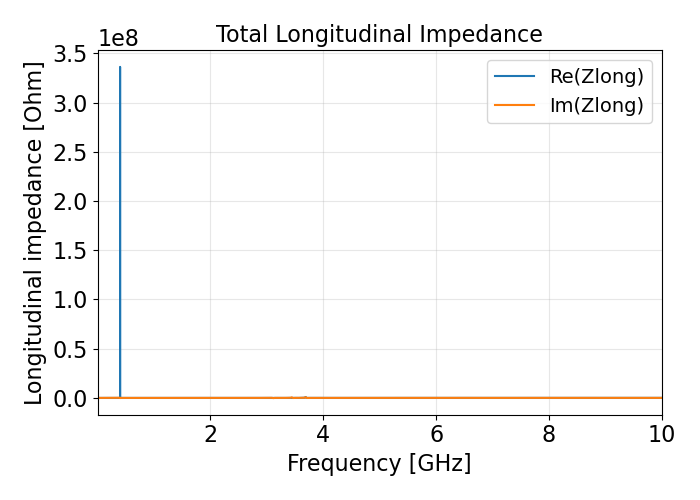

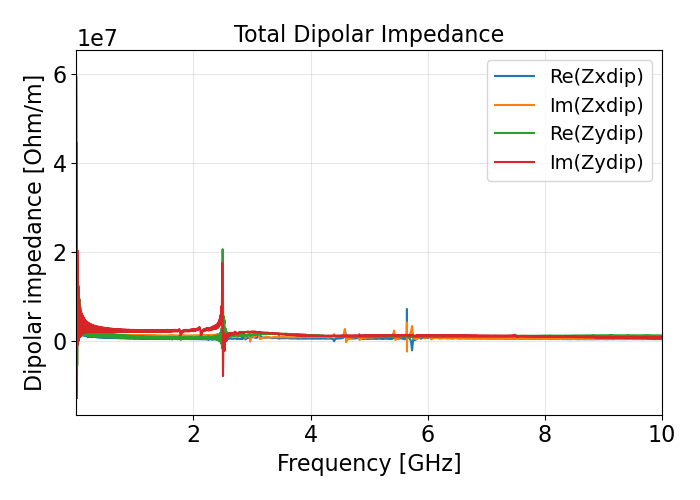

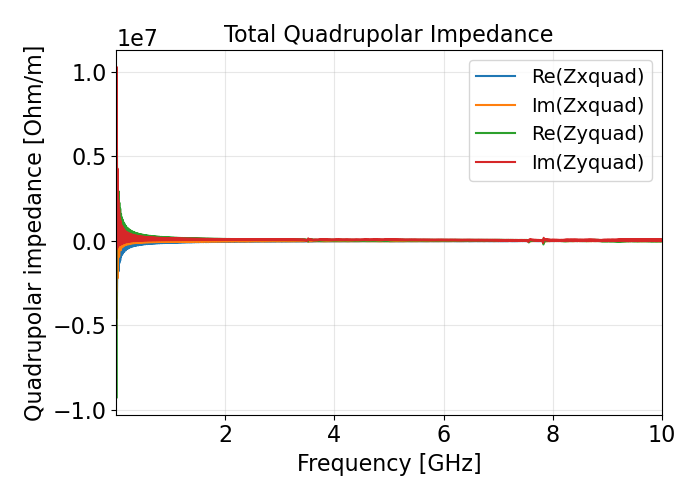

In [18]:

plot_total_impedance(freq_loaded,Zlong_loaded,Zxdip_loaded,Zydip_loaded,Zxquad_loaded,Zyquad_loaded,filename=total_file.name,image_folder=PLOTS_FOLDER ,xlim=(1e-3, 10),show=True,save=False,);